# 🚗 **AICE ASSOCIATE 제1회 실전모의고사**


## **중고차 가격 예측**
---
* **도메인** : 자동차 유통  
* **목 표** : 중고차의 합리적인 **판매 가격을 예측**하는 인공지능 모델 개발  
* 국내 최대 중고차 플랫폼 '카셀'은 판매자와 소비자 간의 정보 비대칭으로 인해 거래 신뢰도가 낮아지고, 차량 판매가 지연되는 문제가 지속적으로 발생하고 있다.  
* 이러한 문제를 해결하기 위해, 카셀의 데이터 분석팀은 차량의 기본 정보, 정비 이력, 사고 기록 등 다양한 데이터를 활용하여 중고차 가격을 예측하는 인공지능 모델을 도입하려 한다.  
---

### **[데이터셋 소개]**
- car_basic_info.csv: 차량의 기본 제원 정보(연식, 주행거리, 연료 등)
- car_history_info.csv: 차량의 사고 이력, 옵션, 이전 소유자 수, 가격 등

### **[데이터 컬럼 설명]**
**1. car_basic_info.csv 파일 컬럼**
* **car_id**: 차량 고유 식별자
* **brand**: 제조사 브랜드 이름(예: Hyundai, Kia, BMW 등)
* **model**: 차량 모델명(예: Avante, Sorento 등)
* **year**: 출고 연도(숫자형, 예: 2017, 2019 등)
* **fuel_type**: 연료 종류(범주형: Gasoline, Diesel 등)
* **transmission**: 변속기 종류(범주형: Auto, Manual 등)
* **engine_size**: 배기량(cc 단위, 예: 1581.1,1898.4 등)
* **price: 차량 판매 가격(단위: 만 원, 숫자형)** <---- 목표 변수

**2. car_history_info.csv 파일 컬럼**
* **car_id**: 차량 고유 식별자
* **mileage**: 누적 주행 거리(단위: km)
* **option_count**: 차량 장착 옵션 개수
* **repair_count**: 정비 이력의 총 횟수
* **repair_cost**: 누적 정비 비용(단위: 만 원)
* **last_repair_date**: 마지막 정비 일자
* **accident_yn**: 사고 이력
* **prev_owners**: 이전 소유자 수

#### **1. 아래 지시사항에 따라 데이터를 불러오고 기본 정보를 확인하세요.**
---
* **(1-1) 데이터 로드 및 병합**
    * pandas 라이브러리를 별칭 `pd`를 사용하여 임포트하세요.
    * `car_basic_info.csv`와 `car_history_info.csv` 두 파일을 각각 불러온 후, 'car_id' 컬럼을 기준으로 병합(inner join)하여 변수 `df`에 저장하시오.
    * 병합된 `df`의 상위 5개 데이터를 출력하세요.
* **(1-2) 문제 유형 판별**
    * 예측할 대상(타깃 변수)은 자동차의 가격을 나타내는 'price' 컬럼입니다. 이 문제의 유형이 '회귀'와 '분류' 중 무엇인지 판단하세요.
---

In [1]:
import pandas as pd

df1 = pd.read_csv('car_basic_info.csv')
df2 = pd.read_csv('car_history_info.csv')

df = pd.merge(df1, df2, on='car_id')

df.head()



,car_id,year,mileage,fuel_type,brand,engine_size,transmission,accident_yn,option_count,prev_owners,repair_cost,price
0,1,2016,107522,Diesel,Kia,NaN,Manual,0,0.0,1,60.711083,2149
1,2,2022,18132,Gasoline,Kia,1581.0,Auto,1,2.0,3,64.514167,2244
2,3,2019,53802,Gasoline,Kia,1898.0,Manual,1,1.0,1,50.475857,2020
3,4,2018,67485,LPG,Kia,1811.0,Manual,0,1.0,1,73.277078,2144
4,5,2013,146270,Gasoline,Hyundai,1733.0,Auto,0,1.0,3,NaN,1330


In [ ]:
# (1-2) 여기에 답안을 입력하세요(실행 불필요).

#### **2. 수집된 중고차 데이터의 전체적인 가격 수준을 파악하기 위해 기초 통계 정보를 확인하려 합니다. 아래 가이드에 따라 평균 가격을 산출하세요.**
---
* 통합 데이터프레임(**`df`**)의 판매 가격(**`price`**) 컬럼에 대한 **평균(mean)** 값을 계산하세요.
* 계산된 평균 값에서 소수점 이하의 자릿수는 모두 버리고, **정수 부분만 추출**하여 출력하세요.
---

In [2]:
price = df['price'].mean()
print(int(price))

1971


> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **3. 브랜드별 중고차 판매 가격의 차이를 파악하기 위해 시각화를 수행하고 결과를 분석하세요.**
---
* **(3-1) 라이브러리를 활용하여 브랜드별 평균 가격을 시각화하세요.**
    * **`seaborn`** 라이브러리를 사용하세요.
    * **`barplot()`** 함수를 사용하여 브랜드(**`brand`**)에 따른 평균 판매 가격(**`price`**)을 막대그래프로 시각화하세요.
* **(3-2) 평균 가격이 가장 높게 나타나는 자동차 브랜드는 무엇인가요?**
---

<Axes: xlabel='brand', ylabel='price'>

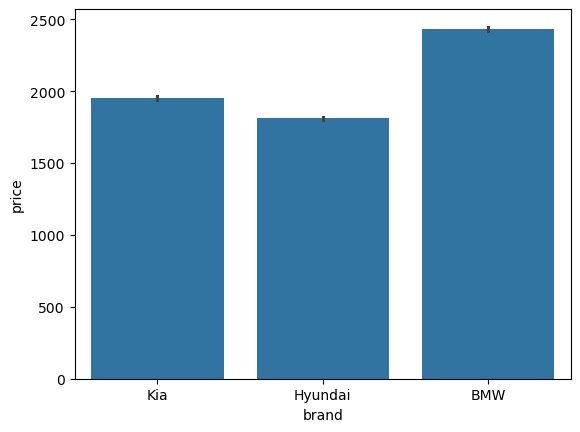

In [4]:
sns.barplot(df, x='brand', y='price')

In [ ]:
# (3-2) 여기에 답안을 입력하세요(실행 불필요)

#### **4. 특정 조건에 해당하는 중고차 데이터를 추출하여 수리 비용의 특성을 분석하세요.**
---
* **(4-1) 'Kia' 브랜드 중 사고 이력이 있는 차량의 수리 비용 평균을 계산하세요.**
    * 제조사가 **'Kia'**이면서 사고 이력이 있는(**`accident_yn == 1`**) 차량 데이터만 필터링하여 추출하세요.
    * 추출된 데이터의 수리 비용(**`repair_cost`**)에 대한 **평균(mean)** 값을 산출하세요.
    * 산출된 평균 값에서 소수점 이하의 자릿수는 모두 버리고, **정수 부분만 출력**하여 결과를 확인하세요.
* **(4-2) 위 조건에 해당하는 차량들의 평균 수리 비용은 얼마인가요?**
---

In [5]:
cond1 = df['brand'] == 'Kia'
cond2 = df['accident_yn'] == 1
cond = df[cond1 & cond2]

repair_cost_mean = cond['repair_cost'].mean()

print(int(repair_cost_mean))


48


In [ ]:
# (4-2) 여기에 답안을 입력하세요(실행 불필요).
# (예시: 150)

#### **5. 데이터에 결측치가 있을 경우 AI 모델링의 성능이 저하될 수 있습니다. 아래 가이드에 따라 결측치를 처리하고 검증하는 코드를 작성하였으나 에러가 발생하고 있습니다. 코드의 오류를 정정하세요.**
---
* **(5-1) 아래 가이드에 따라 코드를 완성하고 실행하세요.**
    * **대상 데이터프레임**: `df`의 사본인 `df_temp`를 생성하여 진행하세요.
    * **배기량(`engine_size`)**: 결측치를 해당 컬럼의 **중앙값**으로 대체하세요.
    * **수리 비용(`repair_cost`), 옵션 개수(`option_count`)**: 결측치를 **0**으로 대체하세요.
    * **이전 소유자 수(`prev_owners`)**: 결측치가 포함된 **행(row)을 모두 삭제**하세요.
    * 전처리가 반영된 데이터프레임은 변수명 `df_na`에 저장하세요.
    * 결측치가 사라졌는지 확인하세요.
* **(5-2) 결측치 처리 전, `df_temp` 데이터프레임에서 결측치가 가장 많이 발생한 컬럼명은 무엇인가요?**
---

In [6]:
# (5-1) 여기에 코드의 오류를 정정하고 실행하세요.
df_temp = df.copy()

print('결측치 처리 전\n', df_temp.isnull().sum())
m_val = df_temp['engine_size'].mean()
df_temp['engine_size'] = df_temp['engine_size'].fillna(m_val)
df_temp[['repair_cost', 'option_count']] = df_temp[['repair_cost', 'option_count']].fillna(0)
df_na = df_temp.dropna(subset=['prev_owners'])
print('\n결측치 처리 후\n', df_temp.isnull().sum())

결측치 처리 전
 car_id             0
year               0
mileage            0
fuel_type          0
brand              0
engine_size      228
transmission       0
accident_yn        0
option_count     188
prev_owners        0
repair_cost     1045
price              0
dtype: int64

결측치 처리 후
 car_id          0
year            0
mileage         0
fuel_type       0
brand           0
engine_size     0
transmission    0
accident_yn     0
option_count    0
prev_owners     0
repair_cost     0
price           0
dtype: int64


In [ ]:
repair_cost

#### **6. 차량 연식('year') 데이터를 활용하여 분석에 용이한 파생변수를 생성하고 데이터를 정제하려 합니다. 아래 가이드에 따라 코드를 완성하세요.**
---
* **대상 데이터프레임: `df_na`**
* 기준 연도를 **2025년**으로 설정하여, **`2025 - year`** 계산 결과를 **'car_age'** 라는 새로운 컬럼에 할당하세요.
* 파생변수를 생성하였으므로, 기존 데이터인 **'year'** 컬럼을 데이터프레임에서 삭제(drop)하세요.
* 데이터프레임의 상단 5개 행을 출력하여 컬럼 생성 및 삭제 결과를 확인하세요.
---

In [7]:
df_na['car_age'] = 2025 - df['year']
df_na = df_na.drop('year', axis=1)

df_na.head()

,car_id,mileage,fuel_type,brand,engine_size,transmission,accident_yn,option_count,prev_owners,repair_cost,price,car_age
0,1,107522,Diesel,Kia,1772.465151,Manual,0,0.0,1,60.711083,2149,9
1,2,18132,Gasoline,Kia,1581.000000,Auto,1,2.0,3,64.514167,2244,3
2,3,53802,Gasoline,Kia,1898.000000,Manual,1,1.0,1,50.475857,2020,6
3,4,67485,LPG,Kia,1811.000000,Manual,0,1.0,1,73.277078,2144,7
4,5,146270,Gasoline,Hyundai,1733.000000,Auto,0,1.0,3,0.000000,1330,12


#### **7. 범주형 데이터를 수치형으로 변환하는 원-핫 인코딩을 수행하고, 학습을 위한 피처와 타깃 데이터를 분리하려 합니다. 아래 가이드에 따라 코드의 빈칸을 채우고 실행하세요.**
---
* **대상 데이터프레임**: `df_na`
* **원-핫 인코딩**: 'fuel_type', 'brand', 'transmission' 컬럼을 대상으로 수행하고 결과를 **`df_encoded`** 에 저장하세요.
* **데이터 분리**
    * **타겟(y)**: 'price' 컬럼을 **`y`** 변수에 할당하세요.
    * **피처(X)**: 'price'와 분석에 불필요한 **'car_id'** 컬럼을 제외한 나머지 컬럼을 **`X`** 변수에 할당하세요.
* **빈칸 채우기**: 아래 코드 셀의 `<#7-1>`, `<#7-2>`, `<#7-3>` 빈칸을 알맞게 채우세요.
* **검증**: `X.info()` 함수를 사용하여 인코딩 결과와 컬럼 구성 상태를 확인하세요.
---

In [8]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
# 원-핫 인코딩 수행
df_encoded = pd.get_dummies(data=df_na, columns=['fuel_type', 'brand', 'transmission'])

# 타겟(y) 및 피처(X) 분리
y = df_encoded['price']
X = df_encoded.drop(columns=['price', 'car_id'], axis=1)

# 데이터셋 구조 확인
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mileage              7000 non-null   int64  
 1   engine_size          7000 non-null   float64
 2   accident_yn          7000 non-null   int64  
 3   option_count         7000 non-null   float64
 4   prev_owners          7000 non-null   int64  
 5   repair_cost          7000 non-null   float64
 6   car_age              7000 non-null   int64  
 7   fuel_type_Diesel     7000 non-null   bool   
 8   fuel_type_Gasoline   7000 non-null   bool   
 9   fuel_type_LPG        7000 non-null   bool   
 10  brand_BMW            7000 non-null   bool   
 11  brand_Hyundai        7000 non-null   bool   
 12  brand_Kia            7000 non-null   bool   
 13  transmission_Auto    7000 non-null   bool   
 14  transmission_Manual  7000 non-null   bool   
dtypes: bool(8), float64(3), int64(4)
memor

In [ ]:
# (7-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (7-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (7-3) 여기에 답안을 입력하세요(실행 불필요).

#### **8. 모델의 성능 평가를 위해 데이터셋을 분리하고, 데이터의 이상치 영향을 낮추기 위해 스케일링을 수행하려 합니다.**

---
* **(8-1) 아래 가이드에 따라 코드의 오류를 정정하고 실행하세요.**
    * **대상 데이터**: 앞서 준비한 피처(`X`)와 타겟(`y`) 데이터를 사용하세요.
    * **데이터셋 분리**
        * **훈련/테스트 비율**: **70:30** 비율로 분할하세요.
        * **변수 저장**: 훈련 데이터는 `X_train`, `y_train`에, 테스트 데이터는 `X_test`, `y_test`에 저장하세요.
        * **난수 시드**: 재현성을 위해 `random_state`를 **42**로 설정하세요.
        * scikit-learn의 train_test_split 함수를 활용하세요
    * **피처 스케일링**
        * sklearn.preprocessing에서 StandardScaler 함수를 import하세요.
        * `StandardScaler`를 사용하여 `scaler` 변수에 저장하세요.
        * **훈련 데이터**: `X_train`을 기준으로 학습과 변환을 동시에 수행하여 **`X_train_scaled`** 에 저장하세요.
        * **테스트 데이터**: 학습된 기준을 그대로 사용하여 `X_test`를 변환하고 **`X_test_scaled`** 에 저장하세요.
* **(8-2) 표준화(StandardScaler)가 정상 처리되었다면 평균이 0에 수렴한다. 훈련 데이터에 대해 평균을 구하고, 이를 반올림하여 0인지 확인하세요.**
---

In [9]:
# (8-1) 여기에 코드의 오류를 정정하고 실행하세요.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
round(X_train_scaled.mean())

0

#### **9. 중고차 판매 가격('price')을 예측하는 머신러닝 모델을 만들려고 합니다. 아래 가이드에 따라 3가지 모델을 생성하고 학습을 수행하세요.**
---
* **LinearRegression**: 모델을 생성하여 **`lr`** 변수에 저장하세요.
* **RandomForestRegressor**: 모델을 생성하여 **`rf`** 변수에 저장하세요. (난수 시드 `random_state`는 **42**로 설정)
* **XGBRegressor**: 모델을 생성하여 **`xgb`** 변수에 저장하세요. (난수 시드 `random_state`는 **42**로 설정)
* 앞서 스케일링을 완료한 훈련 데이터셋을 사용하여 세 모델을 각각 학습시키세요.
* 하이퍼파라미터는 제시된 내용 외 별도로 입력하지 마세요.
---

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### **10. 학습시킨 모델들의 예측 성능을 평가하고, 가장 우수한 성과를 보인 최적 모델을 선정하려고 합니다. 아래 가이드에 따라 코드의 오류를 정정하고 실행하세요.**
---
* **(10-1) 아래 가이드에 따라 각 모델의 RMSE를 산출하고 최적 모델을 선정하세요.**
    * 성능 평가는 검증 데이터셋을 활용하세요.
    * 앞서 만든 모델로 예측을 수행하여 각각 **`y_pred_lr`**, **`y_pred_rf`**, **`y_pred_xgb`** 에 저장하세요.
    * 각 모델의 **RMSE**를 산출하고 **`rmse_lr`**, **`rmse_rf`**, **`rmse_xgb`** 변수에 저장하세요.
    * 세 모델의 RMSE 값을 모두 출력하세요.
* **(10-2) 세 모델의 RMSE를 비교하여 가장 성능이 우수한 모델을 작성하시오**(※ 단, 모델 이름은 `LinearRegression`, `RandomForestRegressor`, `XGBRegressor` 중 하나여야 함).
---

In [17]:
# (10-1) 여기에 코드의 오류를 정정하고 실행하세요.
from sklearn.metrics import root_mean_squared_error

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(rmse_lr, rmse_rf, rmse_xgb)

148.4228447998824 161.59887446007136 165.3726043701172


In [ ]:
# (10-2) 여기에 답안을 입력하세요(실행 불필요).

> **<span style="color:red">다음 문항을 풀기 전에 </span>아래 코드를 실행하세요.**
>

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(100)

#### **11. 중고차 판매 가격('price')을 예측하는 딥러닝 모델을 만들려고 합니다. 아래 토폴로지 다이어그램과 가이드를 참고하여 모델을 구성하세요.**
---
- tensorflow 프레임워크를 사용하고 하단의 토폴로지 그림과 동일한 딥러닝 모델을 구현하세요.
- 히든 레이어의 activation 함수는 'relu'를, 마지막 아웃풋 레이어의 activation 함수는 'linear'를 사용하세요.
- dl_model 변수에 저장하고 모델의 전체 구조를 출력하세요.
----

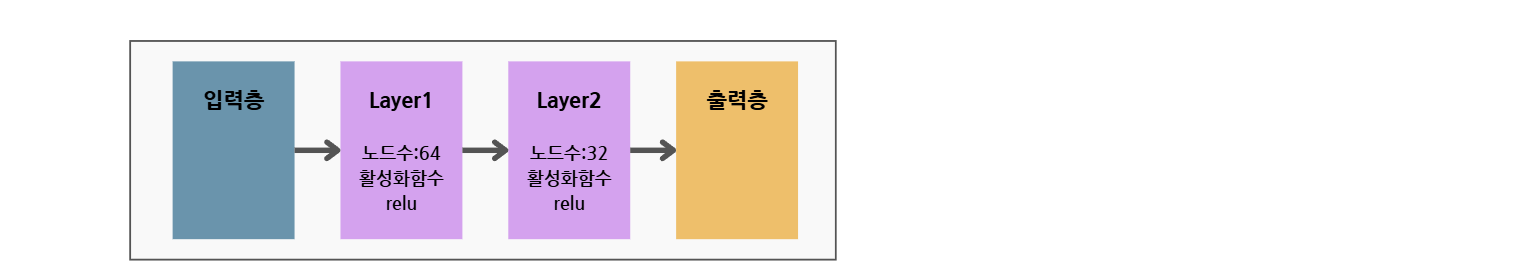

In [22]:
dl_model = Sequential()
dl_model.add(Dense(units=64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(Dense(units=32, activation='relu'))
dl_model.add(Dense(units=1, activation='linear'))

dl_model.summary()

C:\Users\kun99\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

#### **12. 딥러닝 모델의 학습 효율을 높이고 과적합을 방지하기 위해 Callback을 설정하여 학습을 수행하려 합니다. 아래 가이드에 따라 코드를 완성하세요.**
---
* 앞서 생성한 **`dl_model`** 을 대상 모델로 사용하세요.
* 검증 손실(**`val_loss`**)이 **5 에포크(epoch)** 동안 개선되지 않으면 학습을 중지하도록 **조기 종료(EarlyStopping)** 를 설정하여 **`early_stopping`** 변수에 저장하세요.
* 학습 과정 중 검증 손실(`val_loss`)이 가장 낮은 **최적의 모델 성능을 보인 시점의 가중치만** **'best_model.keras'** 파일로 저장하도록 **ModelCheckpoint**를 설정하여 **`model_checkpoint`** 변수에 저장하세요.
* 모델 컴파일 시 최적화 알고리즘은 **'adam'** 으로, 손실 함수는 **'mean_squared_error'** 로 설정하세요.
* 모델 학습은 **50 에포크(epochs)** 동안 수행하며, **배치 크기(batch_size)는 32**로 지정하세요.
* 검증 데이터로 **`X_test_scaled`** 와 **`y_test`** 를 투입하고, 정의한 **두 가지 Callback 기능을 모두 적용**하여 학습 과정의 기록을 **`history`** 변수에 저장하세요.
---

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5)
model_checkpoint = ModelCheckpoint(monitor='val_loss', filepath='best_model.keras', save_best_only=True)

dl_model.compile(optimizer='adam', loss='mean_squared_error')

history = dl_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32,
                       validation_data=(X_test_scaled, y_test), callbacks=[early_stopping, model_checkpoint])


Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3929076.0000 - val_loss: 3709144.0000
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2966254.7500 - val_loss: 1971611.0000
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 992157.0625 - val_loss: 342487.8438
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 162729.5156 - val_loss: 96898.1875
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 74133.8516 - val_loss: 64170.0938
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54010.7344 - val_loss: 50603.9414
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44381.9453 - val_loss: 43718.6758
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 39377.1836 - val_loss: 39893.5508
Epoch 9/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36530.3359 - val_loss: 37505.2461
Epoch 10/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 34681.2461 - val_loss: 35795.7500
Epoch 11/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

#### **13. 앞서 학습시킨 딥러닝 모델의 일반화 성능(Generalization Performance)을 평가하려 합니다. matplotlib 라이브러리를 활용하여 학습 손실(Loss)과 검증 손실(val_loss)의 변화를 시각화하세요.**
---
* **아래 가이드에 따라 학습 이력을 시각화하는 코드를 완성하고 실행하세요.**
    * 학습 정보가 담긴 **`history.history`** 딕셔너리를 활용하여 훈련 손실('loss')과 검증 손실('val_loss')을 하나의 그래프에 표시하세요.
    * 훈련 손실의 범례는 **'Training Loss'** 로, 검증 손실의 범례는 **'Validation Loss'** 로 각각 지정하세요.
    * 그래프의 제목(Title)은 **'Model Loss Over Epochs'** 로 설정하세요.
    * X축의 이름은 **'Epoch'** 로, Y축의 이름은 **'Loss (MSE)'** 로 표시하세요.
    * 두 곡선을 구분할 수 있도록 **범례(legend)** 를 표시하고 그래프를 화면에 출력하세요.
* 아래 코드 셀의 `<#13-1>`, `<#13-2>`, `<#13-3>` 빈칸을 알맞게 채우세요.
---

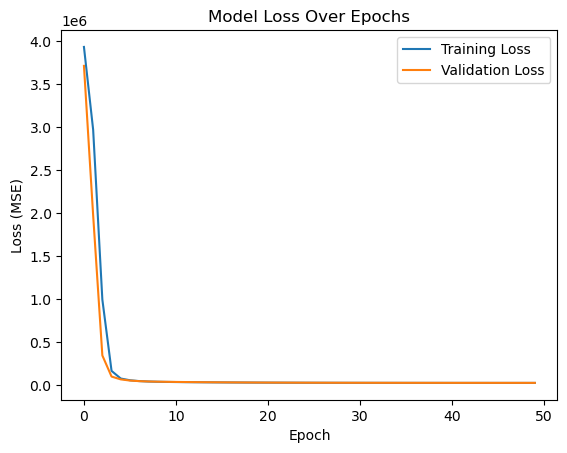

In [26]:
# (코드 셀) 코드의 빈칸을 채우고 실행하세요.
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

In [ ]:
# (13-1) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-2) 여기에 답안을 입력하세요(실행 불필요).

In [ ]:
# (13-3) 여기에 답안을 입력하세요(실행 불필요).

#### **14. 앞서 저장한 최적의 딥러닝 모델을 활용하여 새로 입고된 중고차의 판매 가격을 예측하려 합니다. 아래 가이드에 따라 예측을 수행하고 결과를 저장하세요.**
---
* 학습 과정 중 저장된 최적의 모델을 불러와 **`loaded_model`** 변수에 저장하세요.
* 제공된 새로운 중고차 정보(**`sample_data`**)를 활용하여 가격 예측을 수행하세요.
* 예측된 결과값(예측 가격)을 추출하여 소수점 둘째 자리까지 출력하여 확인하세요.
---

> **<span style="color:red">아래 코드를 사전에 </span> 실행하세요.**
>

In [27]:
# 새로 입고된 중고차 정보(전처리가 완료된 상태)
import numpy as np
sample_data=np.array([[-0.54, -0.53, 1.53, 2.79, 0.29, 17.8, -1.51, -0.68, 0.85, -0.35, -0.49, -1.01, 1.52, 0.5, -0.5]])

In [30]:
loaded_model = load_model('best_model.keras')

Pred = loaded_model.predict(sample_data)[0][0]

print(round(Pred, 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


TypeError: type numpy.ndarray doesn't define __round__ method